In [1]:
import warnings
warnings. filterwarnings('ignore')

import pandas as pd
import numpy as np
from shapely.geometry import Point, LineString
from shapely.ops import transform
import matplotlib.pyplot as plt
import movingpandas as mpd
import geopandas as gpd
import pyproj

%matplotlib inline

In [2]:
#Transformation function to calculate degrees to m (WGS84 to RD)
wgs_deg = pyproj.CRS('EPSG:4326')
rd_m = pyproj.CRS('EPSG:28992')
deg_to_m = pyproj.Transformer.from_crs(wgs_deg, rd_m, always_xy=True).transform

In [3]:
#Transect that goes through the center of the lock chambers at the Kreekrak
Volkerak_center_transect = LineString([Point(4.4082,51.6912),Point(4.4105,51.6896)])
Kreekrak_center_transect = LineString([Point(4.2285293,51.4479159),Point(4.2325848,51.4482870)])

length_chamber = 320 #meters

In [4]:
#Reading data --> pick the right file!
# Kreekrak file
vessel_df_kreekrak = pd.read_csv(r"C:\Users\929509\OneDrive - Delft University of Technology\1. Thesis files\Python\AIS\September_Kreekrak.csv")

# Overpass turbo doesnt work for kreekrak --> do manually
# lock_geometry = gpd.read_file(r"C:\Users\929509\OpenTNSim\notebooks\Test Angelina\data\lock_chamber.geojson")
# lock_polygon = lock_geometry.geometry.iloc[0]   # the polygon

# Manual polygon coordinates of Kreekrak Oostkolk
lock_polygon = [
[4.2312223, 51.4466555],
[4.2317265, 51.4467023],
[4.2310989, 51.4495942],
[4.2306054, 51.4495675],
[4.2312223, 51.4466555]
]

#Selecting data
# vessel_df_kreekrak = vessel_df[((vessel_df.latitude_deg > 51.4334106)&
#                                 (vessel_df.latitude_deg < 51.4619220)&
#                                 (vessel_df.longitude_deg > 4.2299938)&
#                                 (vessel_df.longitude_deg < 4.2371178))]

# FOR SINGLE VESSLE
#Creating trajectory
# trajectory = mpd.Trajectory(vessel_df_volkerak,traj_id='244010511',x='longitude_deg',y='latitude_deg',t='receivedAt')

# #and adding distance
# trajectory.add_distance()

# #Getting geometry and geometry dataframe (in geopandas)
# trajectory_linestring = trajectory.to_linestring()
# trajectory_gdf = trajectory.to_point_gdf()

# #Calculating the cumulative distance
# trajectory_gdf['distance_cumulative'] = trajectory_gdf['distance'].cumsum()

# #Transforming to RD
# trajectory_linestring_m = transform(deg_to_m, trajectory_linestring)
# Volkerak_center_transect_m = transform(deg_to_m, Volkerak_center_transect)

# #Getting distance until vessel reaches lock center
# intersection_point = trajectory_linestring_m.intersection(Volkerak_center_transect_m)
# length_before_crossing = trajectory_linestring_m.project(intersection_point)

# #Correct cumulative distance
# trajectory_gdf.distance_cumulative = trajectory_gdf.distance_cumulative - length_before_crossing;

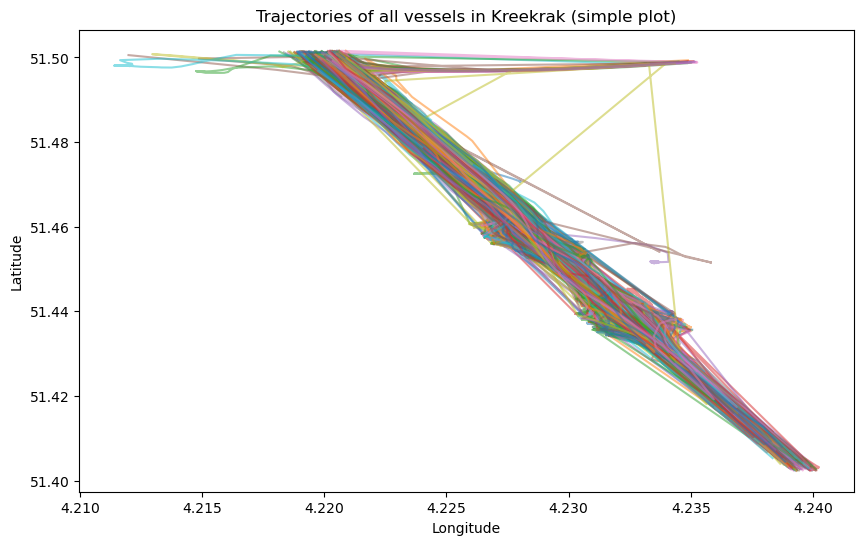

In [5]:
# Quick plot of all vessel trajectories

fig, ax = plt.subplots(figsize=(10, 6))

# Group by vessel
groups = vessel_df_kreekrak.groupby("mmsi")

# Sorting values based on time 
for mmsi, df_single in groups:
    df_single = df_single.sort_values("receivedAt")
    ax.plot(df_single["longitude_deg"], df_single["latitude_deg"], alpha=0.5)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Trajectories of all vessels in Kreekrak (simple plot)")

plt.show()

In [6]:
# DONT REMOVE
# ORIGINAL VERSION WITHOUT WEST/EASTBOUND
# all_trajectories = []

# for mmsi, df_single in vessel_df_volkerak.groupby("mmsi"):

#     if len(df_single) < 5:
#         continue

#     # Create trajectory
#     trajectory = mpd.Trajectory(
#         df_single,
#         traj_id=mmsi,
#         x='longitude_deg',
#         y='latitude_deg',
#         t='receivedAt'
#     )

#     trajectory.add_distance()

#     #Getting geometry and geometry dataframe (in geopandas
#     trajectory_linestring = trajectory.to_linestring()
#     trajectory_gdf = trajectory.to_point_gdf()

#     #Calculating the cumulative distance
#     trajectory_gdf['distance_cumulative'] = trajectory_gdf['distance'].cumsum()

#     # Convert to meters
#     trajectory_linestring_m = transform(deg_to_m, trajectory_linestring)
#     center_line_m = transform(deg_to_m, Volkerak_center_transect)

#     # FILTER: keep only vessels entering the Oostkolk polygon 
#     if not trajectory_linestring.intersects(lock_polygon):
#         continue

#     # Intersection with center line 
#     intersection_point = trajectory_linestring_m.intersection(center_line_m)

#     # Only accept simple, single-point intersections
#     if intersection_point.is_empty or (not isinstance(intersection_point, Point)):
#         continue

#     # Project to get length difference 
#     length_before_crossing = trajectory_linestring_m.project(intersection_point)

#     # Shift cumulative distances
#     trajectory_gdf['distance_cumulative'] -= length_before_crossing
#     trajectory_gdf['mmsi'] = mmsi

#     all_trajectories.append(trajectory_gdf)


In [7]:
# Tried to fix the direction with west and eastbound --> north and south now
all_trajectories = []

for mmsi, df_single in vessel_df_kreekrak.groupby("mmsi"):

    if len(df_single) < 15:
        continue

    # sort chronologically
    df_single = df_single.sort_values("receivedAt")

    # --- Simple direction detection ---
    start_lon = df_single["longitude_deg"].iloc[0]
    end_lon   = df_single["longitude_deg"].iloc[-1]
    southbound = end_lon < start_lon

    # --- THE REAL FIX: reverse dataframe for southbound ---
    if southbound:
        df_single = df_single.iloc[::-1].reset_index(drop=True)

    # Create trajectory using correct direction ordering
    trajectory = mpd.Trajectory(
        df_single,
        traj_id=mmsi,
        x='longitude_deg',
        y='latitude_deg',
        t='receivedAt'
    )

    trajectory.add_distance()
    trajectory_linestring = trajectory.to_linestring()
    trajectory_gdf = trajectory.to_point_gdf()

    trajectory_gdf['distance_cumulative'] = trajectory_gdf['distance'].cumsum()

    # Convert to meters
    trajectory_linestring_m = transform(deg_to_m, trajectory_linestring)
    center_line_m = transform(deg_to_m, Kreekrak_center_transect)

    # FILTER for lock polygon 
    if not trajectory_linestring.intersects(lock_polygon):
        continue

    # Intersection
    intersection_point = trajectory_linestring_m.intersection(center_line_m)
    if intersection_point.is_empty or (not isinstance(intersection_point, Point)):
        continue

    length_before_crossing = trajectory_linestring_m.project(intersection_point)

    # Shift so lock center = 0
    trajectory_gdf['distance_cumulative'] -= length_before_crossing

    # --- restore sign (eastbound positive, southbound negative) ---
    if southbound:
        trajectory_gdf['distance_cumulative'] *= -1

    trajectory_gdf['mmsi'] = mmsi
    all_trajectories.append(trajectory_gdf)


TypeError: One of the arguments is of incorrect type. Please provide only Geometry objects.

In [8]:
full_df = pd.concat(all_trajectories)

fig, ax = plt.subplots()
for mmsi, df_single in full_df.groupby("mmsi"):
    ax.plot(df_single.distance_cumulative, df_single.index, alpha=0.5)

ylim_min, ylim_max = ax.get_ylim()
ax.fill(
    [-length_chamber/2, -length_chamber/2, length_chamber/2, length_chamber/2],
    [ylim_min, ylim_max, ylim_max, ylim_min],
    color='grey',
    alpha=0.2,
    zorder=-1
)

ax.set_ylim(ylim_min, ylim_max)
plt.show()

ValueError: No objects to concatenate

In [9]:
# Plotting per day for week data
# --- Make a daily label based on the index ---
# First convert index to datetime if needed
try:
    idx_times = pd.to_datetime(full_df.index)
except:
    # If index already datetime-like:
    idx_times = full_df.index

full_df["day"] = idx_times.date

# --- Get unique 7 days ---
unique_days = sorted(full_df["day"].unique())[:7]

# --- 7 subplots ---
fig, axes = plt.subplots(6, 1, figsize=(11, 30), sharex=True)

for ax, day in zip(axes, unique_days):

    df_day = full_df[full_df["day"] == day]

    # plot each vessel
    for mmsi, df_single in df_day.groupby("mmsi"):
        ax.plot(df_single.distance_cumulative, df_single.index, alpha=0.5)

    # shade lock chamber
    ylim_min, ylim_max = ax.get_ylim()
    ax.fill(
        [-length_chamber/2, -length_chamber/2,
         length_chamber/2,  length_chamber/2],
        [ylim_min, ylim_max, ylim_max, ylim_min],
        color='grey', alpha=0.2, zorder=-1
    )
    ax.set_ylim(ylim_min, ylim_max)
    ax.set_title(str(day))

plt.tight_layout()
plt.show()

NameError: name 'full_df' is not defined

In [ ]:
# fig,ax = plt.subplots()
# ax.plot(trajectory_gdf.distance_cumulative,trajectory_gdf.index)
# ylim_min,ylim_max = ax.get_ylim()

# ax.fill([-length_chamber/2,-length_chamber/2,length_chamber/2,length_chamber/2],[ylim_min,ylim_max,ylim_max,ylim_min],color='grey',zorder=-1,alpha=0.2)
# ax.set_ylim(ylim_min,ylim_max)